# Adversarial Attacks on Traffic Sign Recognition (corrected re-run)
Bug fixes are marked `# FIX`. The first cell mounts Drive, copies data, and makes the run resumable: models are saved to Drive and finished steps are skipped on re-run. Results are appended to `results.jsonl` on Drive.

In [1]:
# === Colab setup (added for the corrected re-run) ===
# Requires: Runtime > Change runtime type > GPU, and a My Drive shortcut to the shared
# "FinalProjectCIS582" folder (right-click the folder in "Shared with me" > Organize > Add shortcut).
import os, json, shutil, subprocess, datetime
from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/FinalProjectCIS582'                      # shared project folder (shortcut)
OUT = '/content/drive/MyDrive/Portfolio-Projects/CIS582-TSR-Adversarial/rerun'  # results + models persist here
os.makedirs(f'{OUT}/model', exist_ok=True)
os.makedirs('./data/LISA', exist_ok=True)
for split in ['training', 'testing']:
    if not os.path.isdir(f'./data/LISA/{split}') or len(os.listdir(f'./data/LISA/{split}')) == 0:
        print('copying LISA', split, '...'); shutil.copytree(f'{SRC}/data/LISA/{split}', f'./data/LISA/{split}', dirs_exist_ok=True)
shutil.copy(f'{SRC}/mask_trial.png', './mask_trial.png')
for d in ['./data/adversarial_GTSRB', './data/adversarial_LISA']:
    os.makedirs(d, exist_ok=True)
if not os.path.islink('./model'):
    if os.path.isdir('./model'): shutil.rmtree('./model')
    os.symlink(f'{OUT}/model', './model')          # models are saved straight to Drive -> survive disconnects
RESULTS = f'{OUT}/results.jsonl'

def done(name, kind):
    if not os.path.exists(RESULTS): return False
    return any(json.loads(l).get('name') == name and json.loads(l).get('kind') == kind for l in open(RESULTS))

def log_result(name, kind, **vals):
    rec = dict(name=name, kind=kind, time=datetime.datetime.utcnow().isoformat(), **{k: round(float(v), 4) for k, v in vals.items()})
    with open(RESULTS, 'a') as f: f.write(json.dumps(rec) + '\n')
    print('LOGGED', rec)

print('GPU:', subprocess.run(['nvidia-smi', '-L'], capture_output=True, text=True).stdout.strip() or 'NONE - switch runtime to GPU!')
print('LISA train/test files:', len(os.listdir('./data/LISA/training')), len(os.listdir('./data/LISA/testing')))


Mounted at /content/drive
copying LISA training ...
copying LISA testing ...
GPU: GPU 0: Tesla T4 (UUID: GPU-cb1fb2b6-9578-db12-330e-2c9e3b0a4b72)
LISA train/test files: 5509 2356


In [2]:
# FIX: the shared LISA folder contains duplicate uploads such as '1234_turnRight (1).png'; drop them so labels parse
import re
dups = [f'./data/LISA/{s}/{f}' for s in ['training', 'testing'] for f in os.listdir(f'./data/LISA/{s}') if re.search(r' \(\d+\)\.', f)]
print('removing', len(dups), 'duplicate files:', sorted(os.path.basename(p) for p in dups))
for p in dups: os.remove(p)
print('LISA train/test files after cleanup:', len(os.listdir('./data/LISA/training')), len(os.listdir('./data/LISA/testing')))

removing 10 duplicate files: ['4303_turnRight (1).png', '4304_stop (1).png', '4305_stop (1).png', '4306_turnRight (1).png', '4307_turnRight (1).png', '4308_turnRight (1).png', '4309_turnRight (1).png', '430_addedLane (1).png', '4310_turnRight (1).png', '4311_turnRight (1).png']
LISA train/test files after cleanup: 5499 2356


## 1. Initialize

### 1.1 Import libraries

In [3]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.utils import save_image
from torchvision import datasets, models, transforms
from torchvision.transforms import ToTensor, Resize, Compose, RandomRotation, RandomPerspective, ColorJitter
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import random
from torch import optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# FIX: reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


In [4]:
# Defining augmentation transform for Datasets
augmentation_transforms = Compose([
    RandomRotation(degrees=5),              # Random rotation upto 5 degrees
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)   # Color jitter
])

### 1.2 GTSRB Dataset

In [5]:
gtsrb_label_map = {
    '0': '20_speed',
    '2': '50_speed',
    '1': '30_speed',
    '3': '60_speed',
    '4': '70_speed',
    '5': '80_speed',
    '6': '80_lifted',
    '7': '100_speed',
    '8': '120_speed',
    '9': 'no_overtaking_general',
    '10': 'no_overtaking_trucks',
    '11': 'right_of_way_crossing',
    '12': 'right_of_way_general',
    '13': 'give_way',
    '14': 'stop',
    '15': 'no_way_general',
    '16': 'no_way_trucks',
    '17': 'no_way_one_way',
    '18': 'attention_general',
    '19': 'attention_left_turn',
    '20': 'attention_right_turn',
    '21': 'attention_curvy',
    '22': 'attention_bumpers',
    '23': 'attention_slippery',
    '24': 'attention_bottleneck',
    '25': 'attention_construction',
    '26': 'attention_traffic_light',
    '27': 'attention_pedestrian',
    '28': 'attention_children',
    '29': 'attention_bikes',
    '30': 'attention_snowflake',
    '31': 'attention_deer',
    '32': 'lifted_general',
    '33': 'turn_right',
    '34': 'turn_left',
    '35': 'turn_straight',
    '36': 'turn_straight_right',
    '37': 'turn_straight_left',
    '38': 'turn_right_down',
    '39': 'turn_left_down',
    '40': 'turn_circle',
    '41': 'lifted_no_overtaking_general',
    '42': 'lifted_no_overtaking_trucks'
}

In [6]:
prohibitory = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16] #(circular, white ground with red border)
mandatory = [33, 34, 35, 36, 37, 38, 39, 40] #(circular, blue ground)
danger = [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31] #(triangular, white ground with red border)

In [7]:
gtsrb_training_data = datasets.GTSRB(root="data", split="train", download=True, transform=Compose([ToTensor(),Resize(size=(48,48))]))
gtsrb_test_data = datasets.GTSRB(root="data", split="test", download=True, transform=Compose([ToTensor(),Resize(size=(48,48))]))

100%|██████████| 187M/187M [00:13<00:00, 14.3MB/s]
100%|██████████| 89.0M/89.0M [00:07<00:00, 11.3MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 212kB/s]


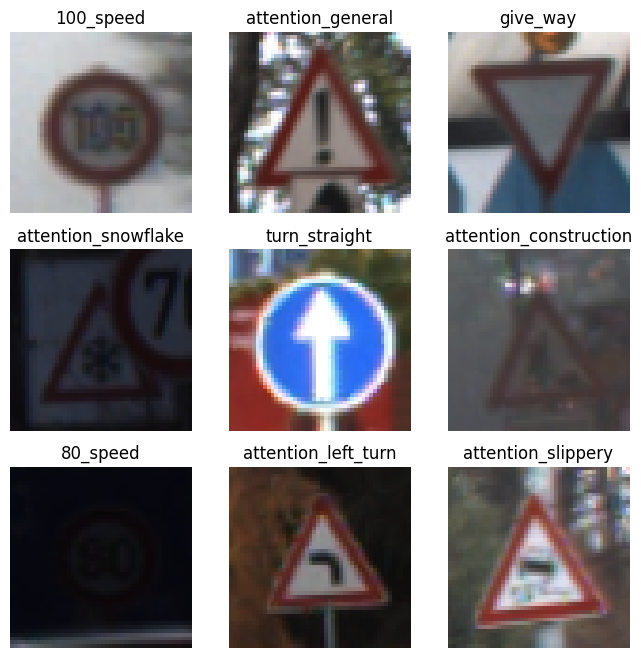

In [8]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(gtsrb_training_data), size=(1,)).item()
    img, label = gtsrb_training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(gtsrb_label_map[f'{label}'])
    plt.axis("off")
    plt.imshow(img.permute((1,2,0)), cmap="gray")
plt.show()

1. Not detecting STOP sign
2. Not detecting YIELD sign
3. Changing the speed limit eg 30 to 80
4. Changing the unit of speed limit
5. Right turn only to no right turn or vice a versa
6. Optional movement lane control, straight through and left turn to leftr turn or vice a versa

### 1.3 GTSRB Augmented Dataset

In [9]:
gtsrb_aug_training_data = datasets.GTSRB(root="data", split="train", download=True, transform=Compose([augmentation_transforms, ToTensor(), Resize(size=(48,48))]))
gtsrb_aug_test_data = datasets.GTSRB(root="data", split="test", download=True, transform=Compose([ToTensor(),Resize(size=(48,48))]))

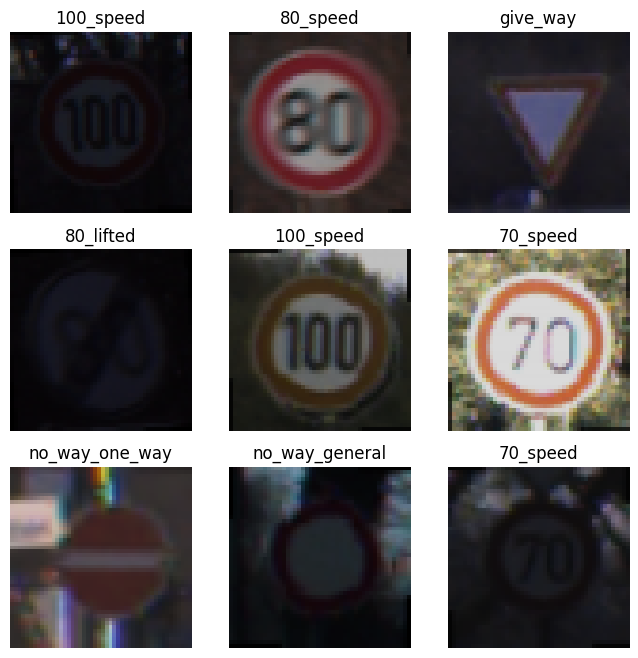

In [10]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(gtsrb_aug_training_data), size=(1,)).item()
    img, label = gtsrb_aug_training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(gtsrb_label_map[f'{label}'])
    plt.axis("off")
    plt.imshow(img.permute((1,2,0)), cmap="gray")
plt.show()

### 1.4 LISA Dataset

In [11]:
lisa_map_label = {
    'addedLane':'0',
    'curveLeft':'1',
    'curveRight':'2',
    'dip':'3',
    'doNotEnter':'4',
    'doNotPass':'5',
    'intersection':'6',
    'keepRight':'7',
    'laneEnds':'8',
    'merge':'9',
    'noLeftTurn':'10',
    'noRightTurn':'11',
    'pedestrianCrossing':'12',
    'rampSpeedAdvisory20':'13',
    'rampSpeedAdvisory35':'14',
    'rampSpeedAdvisory40':'15',
    'rampSpeedAdvisory45':'16',
    'rampSpeedAdvisory50':'17',
    'rampSpeedAdvisoryUrdbl':'18',
    'rightLaneMustTurn':'19',
    'roundabout':'20',
    'school':'21',
    'schoolSpeedLimit25':'22',
    'signalAhead':'23',
    'slow':'24',
    'speedLimit15':'25',
    'speedLimit25':'26',
    'speedLimit30':'27',
    'speedLimit35':'28',
    'speedLimit40':'29',
    'speedLimit45':'30',
    'speedLimit50':'31',
    'speedLimit55':'32',
    'speedLimit65':'33',
    'speedLimitUrdbl':'34',
    'stop':'35',
    'stopAhead':'36',
    'thruMergeLeft':'37',
    'thruMergeRight':'38',
    'thruTrafficMergeLeft':'39',
    'truckSpeedLimit55':'40',
    'turnLeft':'41',
    'turnRight':'42',
    'yield':'43',
    'yieldAhead':'44',
    'zoneAhead25':'45',
    'zoneAhead45':'46'
}

In [12]:
lisa_label_map = {v:k for k, v in lisa_map_label.items()}

In [13]:
class LISADataset(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform
        self.images = os.listdir(path)
    def __getitem__(self, index):
        img_name = os.path.join(self.path, self.images[index])
        image = Image.open(img_name)
        if self.transform:
            image = self.transform(image)
        label = int(lisa_map_label[self.images[index].split('_')[1][:-4]])
        return image, label
    def __len__(self):
        return len(self.images)

In [14]:
lisa_training_data = LISADataset(path="./data/LISA/training", transform=Compose([ToTensor(),Resize(size=(48,48))]))
lisa_test_data = LISADataset(path="./data/LISA/testing", transform=Compose([ToTensor(),Resize(size=(48,48))]))

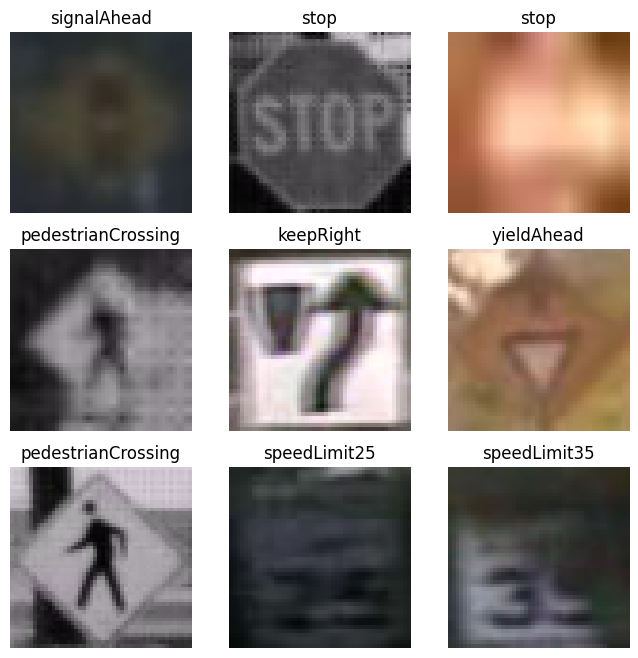

In [15]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(lisa_training_data), size=(1,)).item()
    img, label = lisa_training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(lisa_label_map[f'{label}'])
    plt.axis("off")
    plt.imshow(img.permute((1,2,0)), cmap="gray")
plt.show()

### 1.5 LISA Augmented Dataset

In [16]:
lisa_aug_training_data = LISADataset(path="./data/LISA/training", transform=Compose([augmentation_transforms, ToTensor(), Resize(size=(48,48))]))
lisa_aug_test_data = LISADataset(path="./data/LISA/testing", transform=Compose([ToTensor(),Resize(size=(48,48))]))

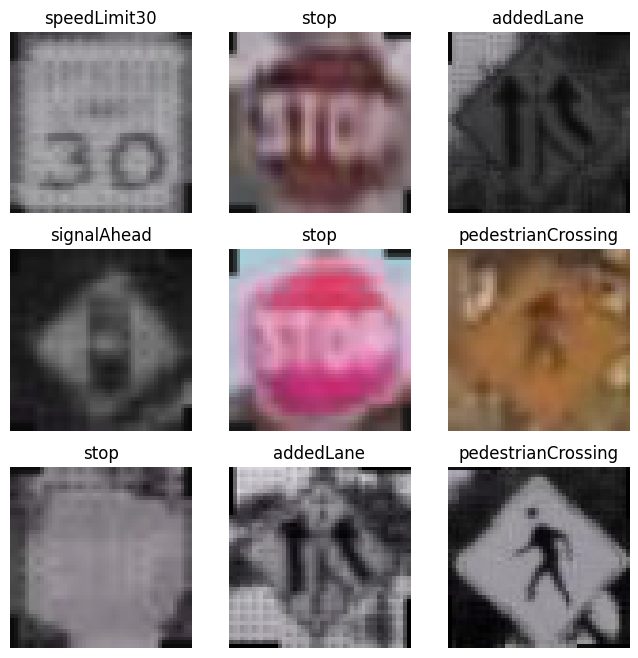

In [17]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(lisa_aug_training_data), size=(1,)).item()
    img, label = lisa_aug_training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(lisa_label_map[f'{label}'])
    plt.axis("off")
    plt.imshow(img.permute((1,2,0)), cmap="gray")
plt.show()

## 2. Traffic Sign Recognition Model Training

### 2.1 Train and Test Functions

In [18]:
# Set batch size
batch_size = 64

# Get cuda, mps or resort to cpu.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [19]:
def train(dataloader, model, loss_func, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute loss
        pred = model(X)
        loss = loss_func(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [20]:
def test(dataloader, model, loss_func):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_func(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    global LAST_TEST_ACC
    LAST_TEST_ACC = correct
    return correct

### 2.2 Model CNN

#### 2.2.1 Model Definition

In [21]:
class CNN(nn.Module):
    def __init__(self, in_channels=3, out_channels=43):
        super(CNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.Flatten(),
            nn.Linear(18432,512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512,out_channels)  # FIX: no Softmax; CrossEntropyLoss expects logits
        )
    def forward(self, x):
        y = self.cnn(x)
        return y

#### 2.2.2 GTSRB-CNN Model Training

In [22]:
train_dataloader = DataLoader(gtsrb_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_test_data, batch_size=batch_size)

In [23]:
if os.path.exists('./model/GTSRB-CNN.pth'):
    print('Found saved GTSRB-CNN, skipping training')
    model = torch.load('./model/GTSRB-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    print(model)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved GTSRB-CNN, skipping training
Test Error: 
 Accuracy: 96.3%, Avg loss: 0.138293 



In [24]:
torch.save(model,'./model/GTSRB-CNN.pth')
if not done('GTSRB-CNN', 'clean'): log_result('GTSRB-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.2.3 Aug-GTSRB-CNN Model Training

In [25]:
train_dataloader = DataLoader(gtsrb_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=batch_size)

In [26]:
if os.path.exists('./model/aug-GTSRB-CNN.pth'):
    print('Found saved aug-GTSRB-CNN, skipping training')
    model = torch.load('./model/aug-GTSRB-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    print(model)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved aug-GTSRB-CNN, skipping training
Test Error: 
 Accuracy: 97.2%, Avg loss: 0.114364 



In [27]:
torch.save(model,'./model/aug-GTSRB-CNN.pth')
if not done('aug-GTSRB-CNN', 'clean'): log_result('aug-GTSRB-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.2.4 LISA-CNN Model Training

In [28]:
train_dataloader = DataLoader(lisa_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_test_data, batch_size=batch_size)

In [29]:
if os.path.exists('./model/LISA-CNN.pth'):
    print('Found saved LISA-CNN, skipping training')
    model = torch.load('./model/LISA-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    print(model)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved LISA-CNN, skipping training
Test Error: 
 Accuracy: 98.8%, Avg loss: 0.043632 



In [30]:
torch.save(model,'./model/LISA-CNN.pth')
if not done('LISA-CNN', 'clean'): log_result('LISA-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.2.5 Aug-LISA-CNN Model Training

In [31]:
train_dataloader = DataLoader(lisa_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=batch_size)

In [32]:
if os.path.exists('./model/aug-LISA-CNN.pth'):
    print('Found saved aug-LISA-CNN, skipping training')
    model = torch.load('./model/aug-LISA-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    print(model)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved aug-LISA-CNN, skipping training
Test Error: 
 Accuracy: 98.3%, Avg loss: 0.066016 



In [33]:
torch.save(model,'./model/aug-LISA-CNN.pth')
if not done('aug-LISA-CNN', 'clean'): log_result('aug-LISA-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

### 2.3 Model RESNET18 FT (Finetuned)

#### 2.3.1 Model Definition

In [34]:
def new_resnet18(n_labels):
    """FIX: build a fresh ImageNet-pretrained ResNet18 for every experiment.
    The original notebook reused one object, so each 'FT' model started from the
    previously fine-tuned weights (e.g. LISA-RESNET18 started from GTSRB weights)."""
    m = models.resnet18(weights='IMAGENET1K_V1')
    m.fc = nn.Linear(m.fc.in_features, n_labels)
    return m

#### 2.3.2 GTSRB-RESNET18-FT Model Training

In [35]:
train_dataloader = DataLoader(gtsrb_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_test_data, batch_size=batch_size)

In [36]:
if os.path.exists('./model/GTSRB-RESNET18-FT.pth'):
    print('Found saved GTSRB-RESNET18-FT, skipping training')
    model = torch.load('./model/GTSRB-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved GTSRB-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 96.4%, Avg loss: 0.171137 



In [37]:
torch.save(model,'./model/GTSRB-RESNET18-FT.pth')
if not done('GTSRB-RESNET18-FT', 'clean'): log_result('GTSRB-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.3.3 Aug-GTSRB-RESNET18-FT Model Training

In [38]:
train_dataloader = DataLoader(gtsrb_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=batch_size)

In [39]:
if os.path.exists('./model/aug-GTSRB-RESNET18-FT.pth'):
    print('Found saved aug-GTSRB-RESNET18-FT, skipping training')
    model = torch.load('./model/aug-GTSRB-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved aug-GTSRB-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 96.0%, Avg loss: 0.163875 



In [40]:
torch.save(model,'./model/aug-GTSRB-RESNET18-FT.pth')
if not done('aug-GTSRB-RESNET18-FT', 'clean'): log_result('aug-GTSRB-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.3.4 LISA-RESNET18-FT Model Training

In [41]:
train_dataloader = DataLoader(lisa_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_test_data, batch_size=batch_size)

In [42]:
if os.path.exists('./model/LISA-RESNET18-FT.pth'):
    print('Found saved LISA-RESNET18-FT, skipping training')
    model = torch.load('./model/LISA-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved LISA-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 98.5%, Avg loss: 0.054363 



In [43]:
torch.save(model,'./model/LISA-RESNET18-FT.pth')
if not done('LISA-RESNET18-FT', 'clean'): log_result('LISA-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 2.3.5 Aug-LISA-RESNET18-FT Model Training

In [44]:
train_dataloader = DataLoader(lisa_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=batch_size)

In [45]:
if os.path.exists('./model/aug-LISA-RESNET18-FT.pth'):
    print('Found saved aug-LISA-RESNET18-FT, skipping training')
    model = torch.load('./model/aug-LISA-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        train(train_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved aug-LISA-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.100671 



In [46]:
torch.save(model,'./model/aug-LISA-RESNET18-FT.pth')
if not done('aug-LISA-RESNET18-FT', 'clean'): log_result('aug-LISA-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

## 3. Adversarial Attack on TSR Model

### 3.1 Adversarial Attack Method: Robust Physical Perturbation

#### 3.1.1 Attack function definition

In [47]:
def adversarial_attack(img, n_labels, model,
                       attack_epochs, target_label = 17,
                       mask_filename="mask_trial.png",
                       attack_lambda_l1 = 0.005, attack_lambda_l2 = 0.001):

    # Mask
    mask = torch.from_numpy(np.array(Image.open(f"{mask_filename}")))
    mask = mask.permute([2,0,1])/255.

    # Noise
    noise = nn.Parameter(torch.rand(img.shape))

    # Loss Function
    loss_func = nn.MSELoss()

    # Optimizer
    optimizer = optim.Adam([noise], lr=0.5)

    # Target Prediction
    target_pred = torch.zeros([1,n_labels])
    target_pred[0][target_label] = 1

    # Pertrubation Optimization
    for i in range(attack_epochs):

        # Noisy Input
        masked_noise = torch.mul(mask,noise)
        noisy_img = torch.clamp(torch.add(img,masked_noise), 0, 1)  # FIX: valid pixel range

        X, y = noisy_img.unsqueeze(0).to(device), target_pred.to(device)

        # Compute loss
        pred = torch.softmax(model(X), dim=1)  # FIX: same objective for CNN and ResNet
        loss = loss_func(pred, y) + attack_lambda_l2*torch.sqrt(torch.sum(torch.pow(masked_noise,2))) + attack_lambda_l1*torch.sum(torch.abs(masked_noise))

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # print(f"attack epoch: {i}\t\tloss: {loss.item():>2f}")

    masked_noise = torch.mul(mask,noise)
    noisy_img = torch.clamp(torch.add(img,masked_noise), 0, 1)
    pred = model(noisy_img.unsqueeze(0).to(device))
    # print(f"\nPredictions = {pred}")
    # print(f"\nPrediction for the adversarial input: {pred.argmax(1)}")
    return noisy_img, masked_noise, pred.argmax(1)

#### 3.1.2 Test adversarial attack on single Input Image

List of labels in this batch:
tensor([26,  5,  8,  7, 21, 12,  8, 38, 19,  5, 19, 16,  1, 42, 38, 18, 38, 12,
         2, 10, 10, 13, 25, 34,  5, 38,  7, 12, 18,  8,  1, 16,  1,  3, 35,  8,
        10, 12, 33, 18, 11,  2, 13, 27, 12, 31, 11, 25,  4,  5,  6, 35,  5,  2,
        13, 26, 17, 25, 23, 31,  9,  4,  8, 35])


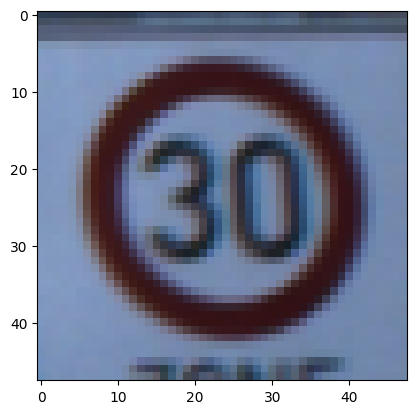

In [48]:
train_dataloader = DataLoader(gtsrb_training_data, batch_size=batch_size, shuffle=True)
temp = next(iter(train_dataloader))
print(f"List of labels in this batch:\n{temp[1]}")
img = temp[0][12]
plt.imshow(img.permute((1,2,0)), cmap="gray")

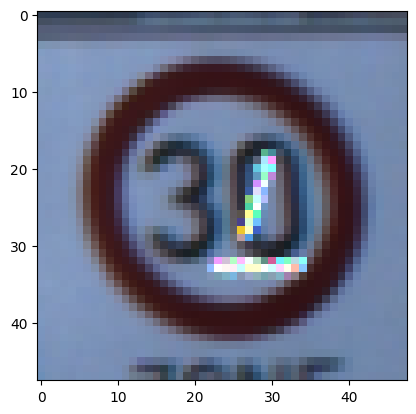

In [49]:
model = CNN()
model = torch.load('./model/GTSRB-CNN.pth', weights_only=False)
model = model.eval()
noisy_image, masked_noise, prediction = adversarial_attack(img, 43, model, attack_epochs = 100,
                                                target_label = 2, mask_filename="mask_trial.png",
                                                attack_lambda_l1=0, attack_lambda_l2=0)
plt.imshow(noisy_image.detach().permute((1,2,0)), cmap="gray")

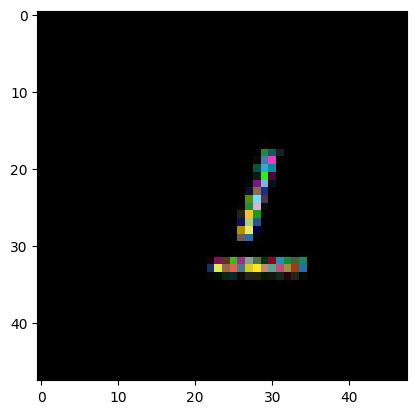

In [50]:
plt.imshow(masked_noise.detach().permute((1,2,0)), cmap="gray")

In [51]:
del model

#### 3.1.3 Adversarial Testing Loop

In [52]:
def test_adversarial(dataloader, model, n_labels,
                     target_label, attack_lambda_l1=0.0001, attack_lambda_l2=0.001,
                     save_img = False, save_path='./data/adversarial'):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    match_groundtruth, match_target, ignore_target  = 0, 0, 0
    all_predictions = []
    all_labels = []
    count = 0
    for X, y in dataloader:
        noisy_image, masked_noise, prediction = adversarial_attack(X.squeeze(0), n_labels,model, attack_epochs = 10,
                                            target_label = target_label, mask_filename="mask_trial.png",
                                            attack_lambda_l1=attack_lambda_l1, attack_lambda_l2=attack_lambda_l2)
        if save_img:
            filename = f"{save_path}/{y.item():05}_{count:05}.ppm"
            save_image(noisy_image, filename)
            count += 1
        match_groundtruth += (prediction.cpu() == y).type(torch.float).sum().item()
        match_target += ((prediction.cpu() == target_label) & (y != target_label)).type(torch.float).sum().item()
        ignore_target += (y.item()==target_label)
        all_predictions.append(prediction)
        all_labels.append(y)
    accuracy = match_groundtruth/ size
    attack_success = match_target / (size - ignore_target)
    print("\n-------------------------------")
    print(f"\nModel Accuracy: {(100*accuracy):>0.1f}%")
    print(f"\nAttack Success Rate: {(100*attack_success):>0.1f}%")
    print("\n-------------------------------")
    return accuracy, attack_success, all_labels, all_predictions

### 3.2 Conducting Adversarial Attack on TSR Model

#### 3.2.1 GTSRB-CNN Model

In [53]:
# Load the model
n_labels = 43
model = CNN(in_channels=3, out_channels=n_labels)
model = torch.load('./model/GTSRB-CNN.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(gtsrb_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('GTSRB-CNN', 'attack'):
    print('attack on GTSRB-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('GTSRB-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on GTSRB-CNN already logged, skipping


#### 3.2.2 Aug-GTSRB-CNN Model

In [54]:
# Load the model
n_labels = 43
model = CNN(in_channels=3, out_channels=n_labels)
model = torch.load('./model/aug-GTSRB-CNN.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('aug-GTSRB-CNN', 'attack'):
    print('attack on aug-GTSRB-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('aug-GTSRB-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on aug-GTSRB-CNN already logged, skipping


#### 3.2.3 LISA-CNN Model

In [55]:
# Load the model
n_labels = 47
model = CNN(in_channels=3, out_channels=n_labels)
model = torch.load('./model/LISA-CNN.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(lisa_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('LISA-CNN', 'attack'):
    print('attack on LISA-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('LISA-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on LISA-CNN already logged, skipping


#### 3.2.4 aug-LISA-CNN Model

In [56]:
# Load the model
n_labels = 47
model = CNN(in_channels=3, out_channels=n_labels)
model = torch.load('./model/aug-LISA-CNN.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('aug-LISA-CNN', 'attack'):
    print('attack on aug-LISA-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('aug-LISA-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on aug-LISA-CNN already logged, skipping


#### 3.2.5 GTSRB-RESNET18-FT Model

In [57]:
# Load the model
n_labels = 43
model = torch.load('./model/GTSRB-RESNET18-FT.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(gtsrb_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('GTSRB-RESNET18-FT', 'attack'):
    print('attack on GTSRB-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('GTSRB-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on GTSRB-RESNET18-FT already logged, skipping


#### 3.2.6 aug-GTSRB-RESNET18-FT Model

In [58]:
# Load the model
n_labels = 43
model = torch.load('./model/aug-GTSRB-RESNET18-FT.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('aug-GTSRB-RESNET18-FT', 'attack'):
    print('attack on aug-GTSRB-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('aug-GTSRB-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on aug-GTSRB-RESNET18-FT already logged, skipping


#### 3.2.7 LISA-RESNET18-FT Model

In [59]:
# Load the model
n_labels = 47
model = torch.load('./model/LISA-RESNET18-FT.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(lisa_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('LISA-RESNET18-FT', 'attack'):
    print('attack on LISA-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('LISA-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on LISA-RESNET18-FT already logged, skipping


#### 3.2.8 aug-LISA-RESNET18-FT Model

In [60]:
# Load the model
n_labels = 47
model = torch.load('./model/aug-LISA-RESNET18-FT.pth', weights_only=False)
model = model.eval()

# Test Dataloader
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('aug-LISA-RESNET18-FT', 'attack'):
    print('attack on aug-LISA-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels, target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('aug-LISA-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)

    all_predictions = [prediction.cpu().numpy() for prediction in all_predictions]
    all_labels = [label.cpu().numpy() for label in all_labels]

    # Create confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    # Display confusion matrix heatmap
    plt.figure(figsize=(12, 12))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(n_labels), yticklabels=range(n_labels))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

attack on aug-LISA-RESNET18-FT already logged, skipping


## 4. Adversarial Training

### 4.1 Adversarial Data Pre-processing

For adversarial training the training set images are given as an input and the images generated by RP2 attack method are stored, which are used during the training loop. The reason for doing this is to reduce the compute time. If the adversarial images are generated on the fly during training then the compute time increases by about 100x. This increase is because RP2 method tries to optimize the noise for each input image individually.
Here only pure datasets (without any augmentation) with CNN classifier are used to generate the adversarial training images.

In [61]:
data_prep = True  # regenerate adversarial training sets with the fixed code

In [62]:
if data_prep and len(os.listdir('./data/adversarial_GTSRB')) == 0:
    # Generate and save the adversarial images - GTSRB
    n_labels = 43
    model = CNN(in_channels=3,out_channels=n_labels)
    model = torch.load('./model/GTSRB-CNN.pth', weights_only=False)

    # Train Dataloader
    train_dataloader = DataLoader(gtsrb_training_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

    # Iterate over Train Set Images
    target_label = 2
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(train_dataloader, model, n_labels,
                                                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.,
                                                                            save_img = True, save_path= './data/adversarial_GTSRB')


-------------------------------

Model Accuracy: 49.2%

Attack Success Rate: 26.4%

-------------------------------


In [63]:
if data_prep and len(os.listdir('./data/adversarial_LISA')) == 0:
    # Generate and save the adversarial images - LISA
    n_labels = 47
    model = CNN(in_channels=3,out_channels=n_labels)
    model = torch.load('./model/LISA-CNN.pth', weights_only=False)

    # Train Dataloader  (FIX: was gtsrb_training_data -> German images with GTSRB labels)
    train_dataloader = DataLoader(lisa_training_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

    # Iterate over Train Set Images
    target_label = 2
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(train_dataloader, model, n_labels,
                                                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.,
                                                                            save_img = True, save_path= './data/adversarial_LISA')


-------------------------------

Model Accuracy: 79.9%

Attack Success Rate: 1.4%

-------------------------------


### 4.2 Adversarial Dataset

In [64]:
class AdversarialDataset(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform
        self.images = os.listdir(path)
    def __getitem__(self, index):
        img_name = os.path.join(self.path, self.images[index])
        image = Image.open(img_name)
        if self.transform:
            image = self.transform(image)
        label = int(self.images[index].split('_')[0])
        return image, label
    def __len__(self):
        return len(self.images)

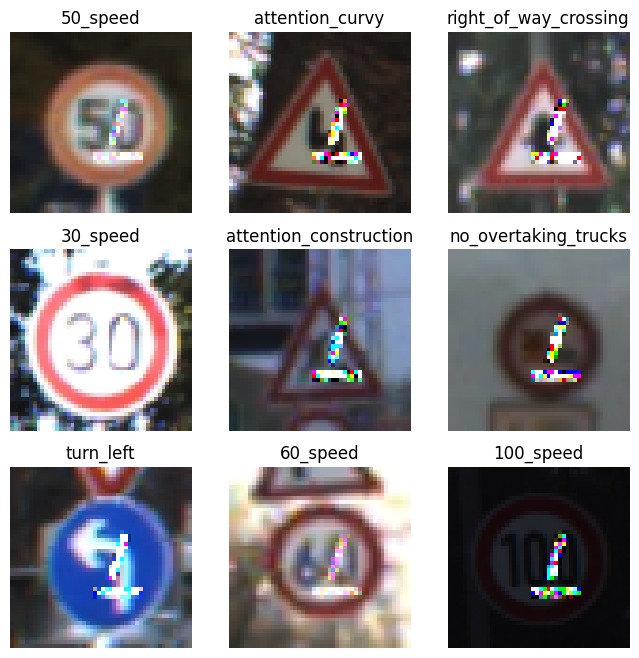

In [65]:
adversarial_data = AdversarialDataset('./data/adversarial_GTSRB', transform=Compose([ToTensor(),Resize(size=(48,48))]))
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(adversarial_data), size=(1,)).item()
    img, label = adversarial_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(gtsrb_label_map[f'{label}'])
    plt.axis("off")
    plt.imshow(img.permute((1,2,0)), cmap="gray")
plt.show()

### 4.3 Adversarial Training definition

In [66]:
def adversarial_train(dataloader, adversarial_dataloader, model, loss_func, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for (batch, (X, y)), (_, (X_adv, y_adv)) in zip(enumerate(dataloader), enumerate(adversarial_dataloader)):
        X, y = X.to(device), y.to(device)
        X_adv, y_adv = X_adv.to(device), y_adv.to(device)

        # Compute loss
        pred = model(X)
        loss = loss_func(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Compute loss for Adversarial Samples
        pred = model(X_adv)
        loss = loss_func(pred, y_adv)

        # Backpropagation for Adversarial Samples
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

### 4.4 Model Training

#### 4.4.1 Adv-GTSRB-CNN

In [67]:
adversarial_data = AdversarialDataset('./data/adversarial_GTSRB', transform=Compose([ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(gtsrb_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_test_data, batch_size=batch_size)

In [68]:
if os.path.exists('./model/adv-GTSRB-CNN.pth'):
    print('Found saved adv-GTSRB-CNN, skipping training')
    model = torch.load('./model/adv-GTSRB-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-GTSRB-CNN, skipping training
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.125395 



In [69]:
# Test Dataloader
test_dataloader = DataLoader(gtsrb_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-GTSRB-CNN', 'attack'):
    print('attack on adv-GTSRB-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-GTSRB-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-GTSRB-CNN already logged, skipping


In [70]:
torch.save(model,'./model/adv-GTSRB-CNN.pth')
if not done('adv-GTSRB-CNN', 'clean'): log_result('adv-GTSRB-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.2 Adv-Aug-GTSRB-CNN

In [71]:
adversarial_data = AdversarialDataset('./data/adversarial_GTSRB', transform=Compose([augmentation_transforms,ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(gtsrb_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=batch_size)

In [72]:
if os.path.exists('./model/adv-aug-GTSRB-CNN.pth'):
    print('Found saved adv-aug-GTSRB-CNN, skipping training')
    model = torch.load('./model/adv-aug-GTSRB-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-aug-GTSRB-CNN, skipping training
Test Error: 
 Accuracy: 97.6%, Avg loss: 0.117312 



In [73]:
# Test Dataloader
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-aug-GTSRB-CNN', 'attack'):
    print('attack on adv-aug-GTSRB-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-aug-GTSRB-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-aug-GTSRB-CNN already logged, skipping


In [74]:
torch.save(model,'./model/adv-aug-GTSRB-CNN.pth')
if not done('adv-aug-GTSRB-CNN', 'clean'): log_result('adv-aug-GTSRB-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.3 Adv-LISA-CNN

In [75]:
adversarial_data = AdversarialDataset('./data/adversarial_LISA', transform=Compose([ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(lisa_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_test_data, batch_size=batch_size)

In [76]:
if os.path.exists('./model/adv-LISA-CNN.pth'):
    print('Found saved adv-LISA-CNN, skipping training')
    model = torch.load('./model/adv-LISA-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-LISA-CNN, skipping training
Test Error: 
 Accuracy: 98.7%, Avg loss: 0.049097 



In [77]:
# Test Dataloader
test_dataloader = DataLoader(lisa_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-LISA-CNN', 'attack'):
    print('attack on adv-LISA-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-LISA-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-LISA-CNN already logged, skipping


In [78]:
torch.save(model,'./model/adv-LISA-CNN.pth')
if not done('adv-LISA-CNN', 'clean'): log_result('adv-LISA-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.4 Adv-Aug-LISA-CNN

In [79]:
adversarial_data = AdversarialDataset('./data/adversarial_LISA', transform=Compose([augmentation_transforms,ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(lisa_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=batch_size)

In [80]:
if os.path.exists('./model/adv-aug-LISA-CNN.pth'):
    print('Found saved adv-aug-LISA-CNN, skipping training')
    model = torch.load('./model/adv-aug-LISA-CNN.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = CNN(in_channels=3, out_channels=n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-aug-LISA-CNN, skipping training
Test Error: 
 Accuracy: 95.9%, Avg loss: 0.131645 



In [81]:
# Test Dataloader
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-aug-LISA-CNN', 'attack'):
    print('attack on adv-aug-LISA-CNN already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-aug-LISA-CNN', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-aug-LISA-CNN already logged, skipping


In [82]:
torch.save(model,'./model/adv-aug-LISA-CNN.pth')
if not done('adv-aug-LISA-CNN', 'clean'): log_result('adv-aug-LISA-CNN', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.5 Adv-GTSRB-RESNET18-FT

In [83]:
adversarial_data = AdversarialDataset('./data/adversarial_GTSRB', transform=Compose([ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(gtsrb_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_test_data, batch_size=batch_size)

In [84]:
if os.path.exists('./model/adv-GTSRB-RESNET18-FT.pth'):
    print('Found saved adv-GTSRB-RESNET18-FT, skipping training')
    model = torch.load('./model/adv-GTSRB-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-GTSRB-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 95.1%, Avg loss: 0.233931 



In [85]:
# Test Dataloader
test_dataloader = DataLoader(gtsrb_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-GTSRB-RESNET18-FT', 'attack'):
    print('attack on adv-GTSRB-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-GTSRB-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-GTSRB-RESNET18-FT already logged, skipping


In [86]:
torch.save(model,'./model/adv-GTSRB-RESNET18-FT.pth')
if not done('adv-GTSRB-RESNET18-FT', 'clean'): log_result('adv-GTSRB-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.6 Adv-Aug-GTSRB-RESNET18-FT

In [87]:
adversarial_data = AdversarialDataset('./data/adversarial_GTSRB', transform=Compose([augmentation_transforms,ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(gtsrb_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=batch_size)

In [88]:
if os.path.exists('./model/adv-aug-GTSRB-RESNET18-FT.pth'):
    print('Found saved adv-aug-GTSRB-RESNET18-FT, skipping training')
    model = torch.load('./model/adv-aug-GTSRB-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 43
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Found saved adv-aug-GTSRB-RESNET18-FT, skipping training
Test Error: 
 Accuracy: 96.5%, Avg loss: 0.157566 



In [89]:
# Test Dataloader
test_dataloader = DataLoader(gtsrb_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-aug-GTSRB-RESNET18-FT', 'attack'):
    print('attack on adv-aug-GTSRB-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-aug-GTSRB-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)


attack on adv-aug-GTSRB-RESNET18-FT already logged, skipping


In [90]:
torch.save(model,'./model/adv-aug-GTSRB-RESNET18-FT.pth')
if not done('adv-aug-GTSRB-RESNET18-FT', 'clean'): log_result('adv-aug-GTSRB-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

#### 4.4.7 Adv-LISA-RESNET18-FT

In [91]:
adversarial_data = AdversarialDataset('./data/adversarial_LISA', transform=Compose([ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(lisa_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_test_data, batch_size=batch_size)

In [92]:
if os.path.exists('./model/adv-LISA-RESNET18-FT.pth'):
    print('Found saved adv-LISA-RESNET18-FT, skipping training')
    model = torch.load('./model/adv-LISA-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


Epoch 1
-------------------------------
loss: 2.846675  [   64/ 5499]
Test Error: 
 Accuracy: 93.7%, Avg loss: 0.211586 

Epoch 2
-------------------------------
loss: 0.087445  [   64/ 5499]
Test Error: 
 Accuracy: 97.3%, Avg loss: 0.081977 

Epoch 3
-------------------------------
loss: 0.040760  [   64/ 5499]
Test Error: 
 Accuracy: 96.6%, Avg loss: 0.112036 

Epoch 4
-------------------------------
loss: 0.026090  [   64/ 5499]
Test Error: 
 Accuracy: 97.5%, Avg loss: 0.098879 

Epoch 5
-------------------------------
loss: 0.028821  [   64/ 5499]
Test Error: 
 Accuracy: 98.9%, Avg loss: 0.032845 

Epoch 6
-------------------------------
loss: 0.088326  [   64/ 5499]
Test Error: 
 Accuracy: 98.0%, Avg loss: 0.079398 

Epoch 7
-------------------------------
loss: 0.004595  [   64/ 5499]
Test Error: 
 Accuracy: 97.7%, Avg loss: 0.091294 

Epoch 8
-------------------------------
loss: 0.005094  [   64/ 5499]
Test Error: 
 Accuracy: 99.0%, Avg loss: 0.032446 

Epoch 9
----------------

In [93]:
# Test Dataloader
test_dataloader = DataLoader(lisa_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-LISA-RESNET18-FT', 'attack'):
    print('attack on adv-LISA-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-LISA-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)



-------------------------------

Model Accuracy: 65.3%

Attack Success Rate: 1.5%

-------------------------------
LOGGED {'name': 'adv-LISA-RESNET18-FT', 'kind': 'attack', 'time': '2026-09-29T00:31:37.560538', 'accuracy_under_attack': 0.6532, 'attack_success_rate': 0.0149}


/tmp/ipykernel_2249/2536177412.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = dict(name=name, kind=kind, time=datetime.datetime.utcnow().isoformat(), **{k: round(float(v), 4) for k, v in vals.items()})


In [94]:
torch.save(model,'./model/adv-LISA-RESNET18-FT.pth')
if not done('adv-LISA-RESNET18-FT', 'clean'): log_result('adv-LISA-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

LOGGED {'name': 'adv-LISA-RESNET18-FT', 'kind': 'clean', 'time': '2026-09-29T00:31:37.722805', 'test_accuracy': 0.9881}


/tmp/ipykernel_2249/2536177412.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = dict(name=name, kind=kind, time=datetime.datetime.utcnow().isoformat(), **{k: round(float(v), 4) for k, v in vals.items()})


#### 4.4.8 Adv-Aug-LISA-RESNET18-FT

In [95]:
adversarial_data = AdversarialDataset('./data/adversarial_LISA', transform=Compose([augmentation_transforms,ToTensor(),Resize(size=(48,48))]))
adversarial_dataloader = DataLoader(adversarial_data, batch_size=batch_size, shuffle=True)
train_dataloader = DataLoader(lisa_aug_training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=batch_size)

In [96]:
if os.path.exists('./model/adv-aug-LISA-RESNET18-FT.pth'):
    print('Found saved adv-aug-LISA-RESNET18-FT, skipping training')
    model = torch.load('./model/adv-aug-LISA-RESNET18-FT.pth', weights_only=False).to(device)
    loss_func = nn.CrossEntropyLoss()
    test(test_dataloader, model, loss_func)
else:
    n_labels = 47
    model = new_resnet18(n_labels).to(device)
    loss_func = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    epochs = 20
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}\n-------------------------------")
        adversarial_train(train_dataloader, adversarial_dataloader, model, loss_func, optimizer)
        test(test_dataloader, model, loss_func)
    print("Done!")

Epoch 1
-------------------------------
loss: 2.929322  [   64/ 5499]
Test Error: 
 Accuracy: 93.8%, Avg loss: 0.212434 

Epoch 2
-------------------------------
loss: 0.408927  [   64/ 5499]
Test Error: 
 Accuracy: 92.5%, Avg loss: 0.273717 

Epoch 3
-------------------------------
loss: 0.264837  [   64/ 5499]
Test Error: 
 Accuracy: 98.0%, Avg loss: 0.064678 

Epoch 4
-------------------------------
loss: 0.114684  [   64/ 5499]
Test Error: 
 Accuracy: 97.8%, Avg loss: 0.081171 

Epoch 5
-------------------------------
loss: 0.092188  [   64/ 5499]
Test Error: 
 Accuracy: 98.0%, Avg loss: 0.070577 

Epoch 6
-------------------------------
loss: 0.032430  [   64/ 5499]
Test Error: 
 Accuracy: 96.7%, Avg loss: 0.107676 

Epoch 7
-------------------------------
loss: 0.143805  [   64/ 5499]
Test Error: 
 Accuracy: 98.7%, Avg loss: 0.044596 

Epoch 8
-------------------------------
loss: 0.077091  [   64/ 5499]
Test Error: 
 Accuracy: 98.7%, Avg loss: 0.055581 

Epoch 9
----------------

In [97]:
# Test Dataloader
test_dataloader = DataLoader(lisa_aug_test_data, batch_size=1) # Batch size should be one, as RP2 works on one image at a time

# Test Set Predictions
target_label = 2
if done('adv-aug-LISA-RESNET18-FT', 'attack'):
    print('attack on adv-aug-LISA-RESNET18-FT already logged, skipping')
else:
    accuracy, attack_success, all_labels, all_predictions = test_adversarial(test_dataloader, model, n_labels,
                                            target_label, attack_lambda_l1=0., attack_lambda_l2=0.)
    log_result('adv-aug-LISA-RESNET18-FT', 'attack', accuracy_under_attack=accuracy, attack_success_rate=attack_success)



-------------------------------

Model Accuracy: 62.6%

Attack Success Rate: 0.6%

-------------------------------
LOGGED {'name': 'adv-aug-LISA-RESNET18-FT', 'kind': 'attack', 'time': '2026-09-29T00:40:21.627793', 'accuracy_under_attack': 0.6261, 'attack_success_rate': 0.0064}


/tmp/ipykernel_2249/2536177412.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = dict(name=name, kind=kind, time=datetime.datetime.utcnow().isoformat(), **{k: round(float(v), 4) for k, v in vals.items()})


In [98]:
torch.save(model,'./model/adv-aug-LISA-RESNET18-FT.pth')
if not done('adv-aug-LISA-RESNET18-FT', 'clean'): log_result('adv-aug-LISA-RESNET18-FT', 'clean', test_accuracy=LAST_TEST_ACC)
torch.cuda.empty_cache()
del model

LOGGED {'name': 'adv-aug-LISA-RESNET18-FT', 'kind': 'clean', 'time': '2026-09-29T00:40:21.767417', 'test_accuracy': 0.9881}


/tmp/ipykernel_2249/2536177412.py:28: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = dict(name=name, kind=kind, time=datetime.datetime.utcnow().isoformat(), **{k: round(float(v), 4) for k, v in vals.items()})


### IF PREPARING NEW MASK

In [99]:
# trial_mask = Image.open('trial_mask.jpg')
# trial_mask = trial_mask.resize((48,48))
# trial_mask.save('mask_trial.png')

In [100]:
# Summary table
import pandas as pd
r = pd.read_json(RESULTS, lines=True)
print(r.pivot_table(index='name', columns='kind', values=['test_accuracy','accuracy_under_attack','attack_success_rate']).round(4))

                          accuracy_under_attack attack_success_rate  \
kind                                     attack              attack   
name                                                                  
GTSRB-CNN                                0.4428              0.2822   
GTSRB-RESNET18-FT                        0.3648              0.1906   
LISA-CNN                                 0.7674              0.0213   
LISA-RESNET18-FT                         0.5531              0.0388   
adv-GTSRB-CNN                            0.8581              0.0287   
adv-GTSRB-RESNET18-FT                    0.6804              0.0418   
adv-LISA-CNN                             0.6728              0.0085   
adv-LISA-RESNET18-FT                     0.6532              0.0149   
adv-aug-GTSRB-CNN                        0.8709              0.0231   
adv-aug-GTSRB-RESNET18-FT                0.7182              0.0330   
adv-aug-LISA-CNN                         0.6817              0.0085   
adv-au